### Regression Exercise 
# Moneyball The NBA
---

### This HW is not easy. TRY IT YOURSELF FIRST! 
Then If you are able to complete it, [watch this lecture series on it](https://ocw.mit.edu/courses/15-071-the-analytics-edge-spring-2017/pages/linear-regression/playing-moneyball-in-the-nba-recitation/video-1-the-data/). 

In [1]:
# PANDAS IS FOR DATA WRANGLING
import pandas as pd
import numpy as np

# SEABORN IS A PLOTTING LIBRARY
import seaborn as sns

# MATPLOT LIB IS ALSO A PLOTTING LIBRARY
import matplotlib.pyplot as plt

# SKLEARN IS OUR MACHINE LEARNING PACKAGE
from sklearn.linear_model import LinearRegression

# IMPORT OUR RANDOM FOREST REGERSSOR
from sklearn.ensemble import RandomForestRegressor

# METRICS HELP US SCORE OUR MODEL
from sklearn import metrics

# HELP US SPLIT OUR DATA INTO TESTING A TRAINING
from sklearn.model_selection import train_test_split

# Good ol statsmodels
import statsmodels.api as sm

# Specific root mean squared error for stats models
from statsmodels.tools.eval_measures import rmse


from statsmodels.stats.outliers_influence import variance_inflation_factor


from statsmodels.api import qqplot

import CTPLIB as ctp


ModuleNotFoundError: No module named 'CTPLIB'

# Remember our main steps motto _isbe_.
1. i - Inspect and explore data.
2. s - Select and engineer features.
3. b - Build and train model.
4. e - Evaluate model.

# STEP 1 (i): Inspect and explore data
1. Use `data/NBA_test.csv and data/NBA_train.csv`

In [2]:
# READ IN THE DATA USING PANDAS 
df = pd.read_csv('NBA_train.csv')

# DISPLAY THE FIRST 5 ROWS
df.head()

,SeasonEnd,Team,Playoffs,W,PTS,oppPTS,FG,FGA,2P,2PA,3P,3PA,FT,FTA,ORB,DRB,AST,STL,BLK,TOV
0,1980,Atlanta Hawks,1,50,8573,8334,3261,7027,3248,6952,13,75,2038,2645,1369,2406,1913,782,539,1495
1,1980,Boston Celtics,1,61,9303,8664,3617,7387,3455,6965,162,422,1907,2449,1227,2457,2198,809,308,1539
2,1980,Chicago Bulls,0,30,8813,9035,3362,6943,3292,6668,70,275,2019,2592,1115,2465,2152,704,392,1684
3,1980,Cleveland Cavaliers,0,37,9360,9332,3811,8041,3775,7854,36,187,1702,2205,1307,2381,2108,764,342,1370
4,1980,Denver Nuggets,0,30,8878,9240,3462,7470,3379,7215,83,255,1871,2539,1311,2524,2079,746,404,1533


```
SeasonEnd: Year season ended
Team: Name of team
Playoffs: If they made the playoffs. 1 == made to playoffs
W: Number of regular season in that season. 
PTS: Points scored in regular season. 
oppPTS: Opponent Points scored in regular season. 
FG: Field Goals made (total shots made == 2P and 3P combined)
FGA: Field Goals attempted (total shots attempted == 2P and 3P combined)
2P: two-pointers made
2PA: two-pointers attempted
3P: three-pointers made
3PA: three-pointers attempted
FT: Free-Throws made (not included in FG stat)
FTA: Free-Throws attempted (not included in FG stat)
ORB: Offensive Rebounds
DRB: Defensive Rebounds
AST: Assists made
STL: Steals 
BLK: Blocks 
TOV: Turnovers 
```

#### Inspect our data using `df.describe()` function.

In [3]:
# Inspect our data using `df.describe()` function.
df.describe()

,SeasonEnd,Playoffs,W,PTS,oppPTS,FG,FGA,2P,2PA,3P,3PA,FT,FTA,ORB,DRB,AST,STL,BLK,TOV
count,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000
mean,1996.319760,0.574850,41.000000,8370.239521,8370.239521,3200.367665,6873.318563,2881.324551,5956.444311,319.043114,916.874251,1650.461078,2189.953293,1061.584431,2427.354491,1912.112575,668.364072,419.805988,1302.837126
std,9.243808,0.494662,12.740822,581.040114,587.543959,287.181266,401.027166,446.097941,830.596327,199.698941,523.982964,197.651728,244.491086,150.224519,130.671523,221.610925,93.393044,82.274913,153.973470
min,1980.000000,0.000000,11.000000,6901.000000,6909.000000,2565.000000,5972.000000,1981.000000,4153.000000,10.000000,75.000000,1189.000000,1475.000000,639.000000,2044.000000,1423.000000,455.000000,204.000000,931.000000
25%,1989.000000,0.000000,31.000000,7934.000000,7934.000000,2974.000000,6563.500000,2510.000000,5269.000000,131.500000,413.000000,1502.500000,2008.000000,953.500000,2346.500000,1735.000000,599.000000,359.000000,1192.000000
50%,1996.000000,1.000000,42.000000,8312.000000,8365.000000,3150.000000,6831.000000,2718.000000,5706.000000,329.000000,942.000000,1628.000000,2176.000000,1055.000000,2433.000000,1899.000000,658.000000,410.000000,1289.000000
75%,2005.000000,1.000000,50.500000,8784.500000,8768.500000,3434.500000,7157.000000,3296.000000,6753.500000,481.500000,1347.500000,1781.000000,2352.000000,1167.000000,2516.500000,2077.500000,729.000000,469.500000,1395.500000
max,2011.000000,1.000000,72.000000,10371.000000,10723.000000,3980.000000,8868.000000,3954.000000,7873.000000,841.000000,2284.000000,2388.000000,3051.000000,1520.000000,2753.000000,2575.000000,1053.000000,716.000000,1873.000000


#### Check for Nulls.

In [4]:
# Check for Nulls.
print("Checking for null values:")
print(df.isnull().sum())

Checking for null values:
SeasonEnd    0
Team         0
Playoffs     0
W            0
PTS          0
oppPTS       0
FG           0
FGA          0
2P           0
2PA          0
3P           0
3PA          0
FT           0
FTA          0
ORB          0
DRB          0
AST          0
STL          0
BLK          0
TOV          0
dtype: int64


#### Check for Duplicates

In [5]:
# Check for Duplicates
print("Number of duplicate rows:")
print(df.duplicated().sum())

Number of duplicate rows:
0


#### Build a function that will INSPECT ANY DATAFRAME FOR YOU do this for you for any data frame you pass into it.

In [6]:
def inspect_dataframe(input_df):
    """
    Comprehensive dataframe inspection function
    Prints shape, data types, null values, duplicates, and basic statistics
    """
    print('\n' + '#'*79)
    print('DATAFRAME INSPECTION')
    print('#'*79 + '\n')
    
    # Shape and size
    print('SHAPE AND SIZE:')
    print(f'  Rows: {input_df.shape[0]:,}')
    print(f'  Columns: {input_df.shape[1]}')
    print()
    
    # Null values
    print('NULL VALUES:')
    null_counts = input_df.isnull().sum()
    if null_counts.sum() == 0:
        print('  No null values found!')
    else:
        print(null_counts[null_counts > 0])
    print()
    
    # Duplicates
    print('DUPLICATE ROWS:')
    dup_count = input_df.duplicated().sum()
    print(f'  {dup_count} duplicate row(s)')
    print()
    
    # Data types
    print('DATA TYPES:')
    print(input_df.dtypes)
    print()
    
    # Basic statistics
    print('BASIC STATISTICS:')
    print(input_df.describe())
    print('\n' + '#'*79)
    
    return "That gooood stuff."

# Test the function
inspect_dataframe(df)


###############################################################################
DATAFRAME INSPECTION
###############################################################################

SHAPE AND SIZE:
  Rows: 835
  Columns: 20

NULL VALUES:
  No null values found!

DUPLICATE ROWS:
  0 duplicate row(s)

DATA TYPES:
SeasonEnd     int64
Team         object
Playoffs      int64
W             int64
PTS           int64
oppPTS        int64
FG            int64
FGA           int64
2P            int64
2PA           int64
3P            int64
3PA           int64
FT            int64
FTA           int64
ORB           int64
DRB           int64
AST           int64
STL           int64
BLK           int64
TOV           int64
dtype: object

BASIC STATISTICS:
         SeasonEnd    Playoffs           W           PTS        oppPTS  \
count   835.000000  835.000000  835.000000    835.000000    835.000000   
mean   1996.319760    0.574850   41.000000   8370.239521   8370.239521   
std       9.243808    0.494662 

'That gooood stuff.'

#### Get a sense of how many wins it will take to make the playoffs. 
Make a scatter plot with x=Wins and the y=Team, and the hue=Playoffs

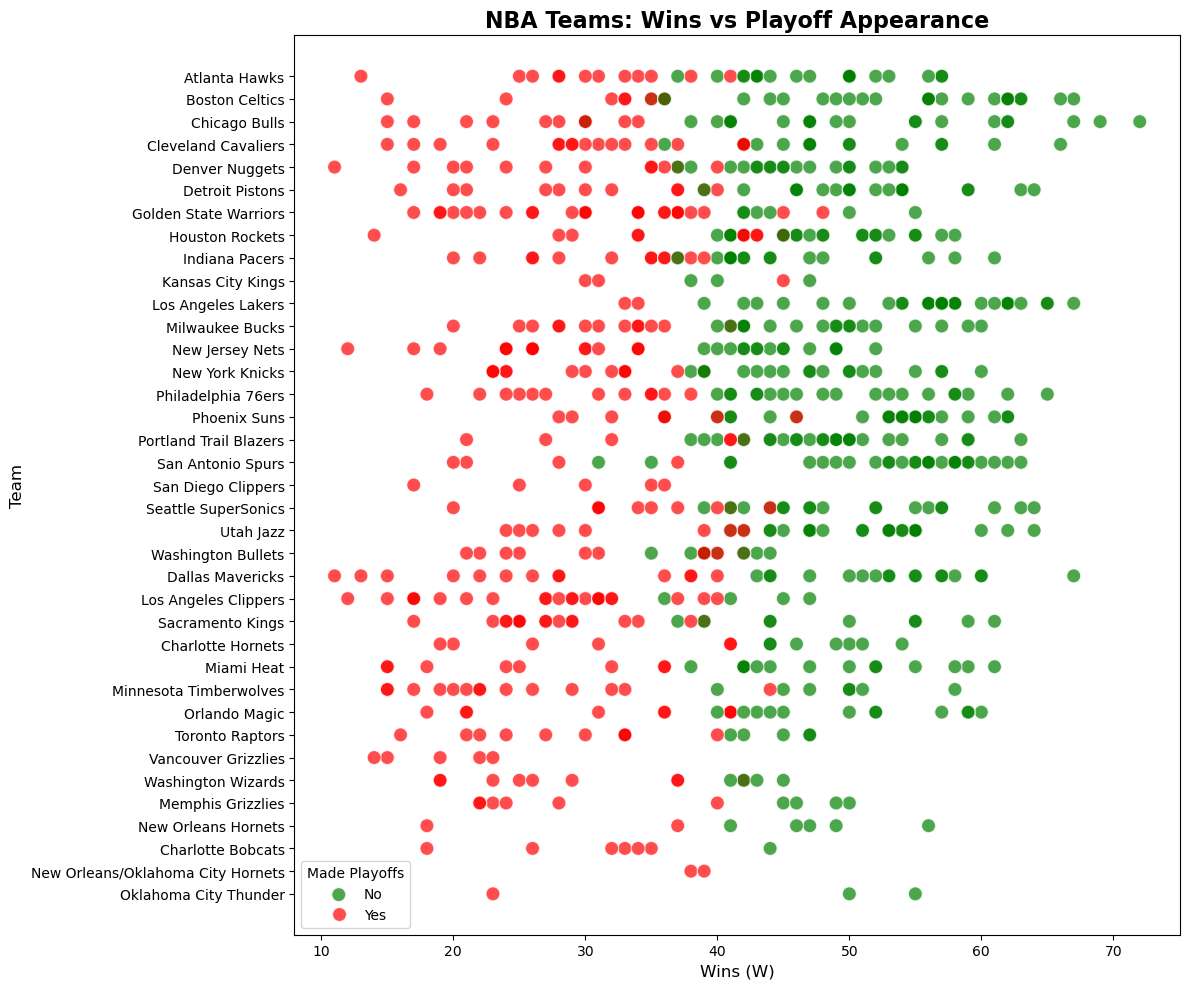

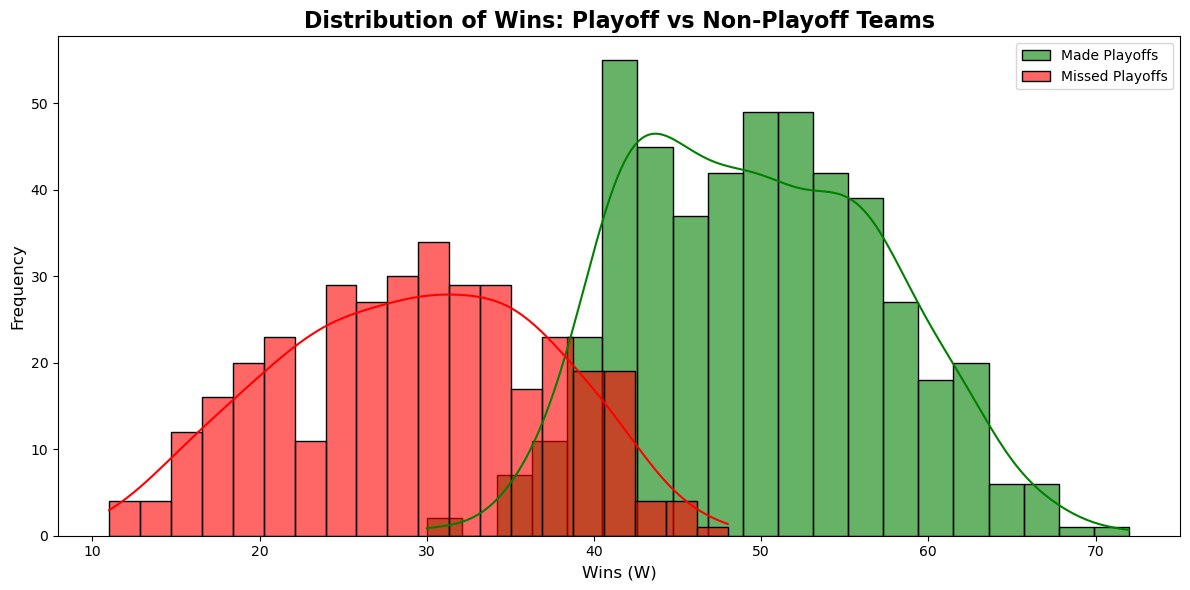

Statistical Analysis:
Playoff teams - Mean wins: 49.75, Min: 30, Max: 72
Non-playoff teams - Mean wins: 29.17, Min: 11, Max: 48


In [7]:
# Get a sense of how many wins it will take to make the playoffs
# Create a scatter plot with x=Wins, y=Team, and hue=Playoffs

plt.figure(figsize=(12, 10))
sns.scatterplot(data=df, x='W', y='Team', hue='Playoffs', palette={0: 'red', 1: 'green'}, s=100, alpha=0.7)
plt.title('NBA Teams: Wins vs Playoff Appearance', fontsize=16, fontweight='bold')
plt.xlabel('Wins (W)', fontsize=12)
plt.ylabel('Team', fontsize=12)
plt.legend(title='Made Playoffs', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

# Let's also create a histogram to see the distribution of wins for playoff vs non-playoff teams
plt.figure(figsize=(12, 6))
sns.histplot(data=df[df['Playoffs']==1], x='W', bins=20, color='green', alpha=0.6, label='Made Playoffs', kde=True)
sns.histplot(data=df[df['Playoffs']==0], x='W', bins=20, color='red', alpha=0.6, label='Missed Playoffs', kde=True)
plt.title('Distribution of Wins: Playoff vs Non-Playoff Teams', fontsize=16, fontweight='bold')
plt.xlabel('Wins (W)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

# Print some statistics to help determine the threshold
print("Statistical Analysis:")
print(f"Playoff teams - Mean wins: {df[df['Playoffs']==1]['W'].mean():.2f}, Min: {df[df['Playoffs']==1]['W'].min()}, Max: {df[df['Playoffs']==1]['W'].max()}")
print(f"Non-playoff teams - Mean wins: {df[df['Playoffs']==0]['W'].mean():.2f}, Min: {df[df['Playoffs']==0]['W'].min()}, Max: {df[df['Playoffs']==0]['W'].max()}")

#### Take a rough estimate, and now use that moving forward.  



In [8]:
# Based on the analysis above, setting a rough estimate for wins needed to make playoffs
# Typically, the minimum wins for playoff teams is around 40-45
WINS_NEED_TO_MAKE_PLAYOFFS = 42

---

# Now do moneyball but for the NBA. 

#### I would like you to do try and do this on your own first.  

It's not easy, but its fun af.  

There is a guided lecture on how to do this that I can send you, but I'd like for you to try and figure it out on your own first.  

If you are fully stuck, ask in slack how other people did it if that doesn't work (I highly encourage collorbration and learning from eachother.  I still consider that doing it on your own.)  

If that doesn't work, DM me and I will send you the lectures explaining how to do the whole thing.

# Rough Guide a v1 model.
0. Make a model to predict PTS 
0. For v1, dont use `2P, 3P, FG, or FT`.  Instead use `2PA, 3PA, FTA`.  
0. Include any other cols use see fit.  


In [9]:
# Build a regression model to predict PTS (Points Scored)
# For v1, don't use 2P, 3P, FG, or FT. Instead use 2PA, 3PA, FTA.
# Include any other cols you see fit.

# First, let's create helper functions similar to the lecture

def eval_regression(input_df, independent_variables, dependent_variable):
    """Evaluate regression model with train/test split"""
    data = input_df.copy()

    # Define the independent and dependent variables
    X = data[independent_variables]
    y = data[dependent_variable]

    # Add a constant to the independent variables (required by statsmodels)
    X = sm.add_constant(X)

    # Split the data into training and test sets (80% train, 20% test)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Build the linear regression model
    model = sm.OLS(y_train, X_train).fit()

    y_pred = model.predict(X_test)
    
    # Rounding the massive long float
    y_pred = round(y_pred, 4)

    # Calculate R^2
    r_squared = metrics.r2_score(y_test, y_pred)
    r_squared = round(r_squared, 4)

    # Calculate RMSE
    model_root_mean_squared_error = rmse(y_test, y_pred)
    model_root_mean_squared_error = round(model_root_mean_squared_error, 4)

    print('R-Squared Score:', r_squared)
    print('RMSE:', model_root_mean_squared_error)
    print('Dependent Variable %s average:' % dependent_variable, round(y.mean(), 4))
    percentage_off = round(model_root_mean_squared_error / y.mean(), 4)
    print(f'On average our prediction is {percentage_off*100}% off from the dependent variable')
    
    return None


def do_moneyball(input_df, independent_variables, dependent_variable, print_model_summary=True):
    """Build and evaluate a regression model using the full dataset"""
    # Copy the data
    data = input_df.copy()

    # Define the independent and dependent variables
    X = data[independent_variables]
    y = data[dependent_variable]

    # Add a constant to the independent variables (required by statsmodels)
    X = sm.add_constant(X)

    # Build the linear regression model
    model = sm.OLS(y, X).fit()
    
    # Make predictions
    y_pred = model.predict(X)

    # Calculate R^2
    r_squared = metrics.r2_score(y, y_pred)
    r_squared = round(r_squared, 4)

    # Calculate RMSE
    model_root_mean_squared_error = rmse(y, y_pred)
    model_root_mean_squared_error = round(model_root_mean_squared_error, 4)

    # Print model description
    print("#"*79)
    print("Predicting:", dependent_variable)
    print("Using:", independent_variables)
    print("#"*79)

    # Print eval metrics
    print('/'*79)
    print('EVAL ON TRAINING DATA (FULL DATASET)')
    print('R-Squared Score:', r_squared)
    print('RMSE:', model_root_mean_squared_error)
    print('Dependent Variable %s average:' % dependent_variable, round(y.mean(), 3))
    print('/'*79)

    print('-'*79)
    print('EVAL ON TEST DATA (WITH TRAIN/TEST SPLIT)')
    print(eval_regression(input_df, independent_variables, dependent_variable))
    print('-'*79)

    # Print the summary of the model if you want it 
    if print_model_summary:   
        print(model.summary())

    return model


# Now let's build our v1 model to predict PTS
print("=" * 79)
print("BUILDING V1 MODEL TO PREDICT PTS")
print("=" * 79)
print()

# Select features - using attempts instead of makes, plus other stats
selected_features = ['2PA', '3PA', 'FTA', 'AST', 'ORB', 'DRB', 'STL']
target_feature = 'PTS'

# Build the model
model_v1 = do_moneyball(df, independent_variables=selected_features, dependent_variable=target_feature)

BUILDING V1 MODEL TO PREDICT PTS

###############################################################################
Predicting: PTS
Using: ['2PA', '3PA', 'FTA', 'AST', 'ORB', 'DRB', 'STL']
###############################################################################
///////////////////////////////////////////////////////////////////////////////
EVAL ON TRAINING DATA (FULL DATASET)
R-Squared Score: 0.8991
RMSE: 184.4733
Dependent Variable PTS average: 8370.24
///////////////////////////////////////////////////////////////////////////////
-------------------------------------------------------------------------------
EVAL ON TEST DATA (WITH TRAIN/TEST SPLIT)
R-Squared Score: 0.902
RMSE: 187.5021
Dependent Variable PTS average: 8370.2395
On average our prediction is 2.2399999999999998% off from the dependent variable
None
-------------------------------------------------------------------------------
                            OLS Regression Results                            
Dep. Varia

### Check for multicollinearity - Correlation Analysis

Correlation Matrix for Selected Features:
       2PA    3PA    FTA    AST    ORB    DRB    STL
2PA  1.000 -0.923  0.524  0.678  0.766 -0.165  0.490
3PA -0.923  1.000 -0.538 -0.593 -0.649  0.223 -0.409
FTA  0.524 -0.538  1.000  0.428  0.475 -0.044  0.370
AST  0.678 -0.593  0.428  1.000  0.407  0.056  0.443
ORB  0.766 -0.649  0.475  0.407  1.000 -0.269  0.493
DRB -0.165  0.223 -0.044  0.056 -0.269  1.000 -0.331
STL  0.490 -0.409  0.370  0.443  0.493 -0.331  1.000



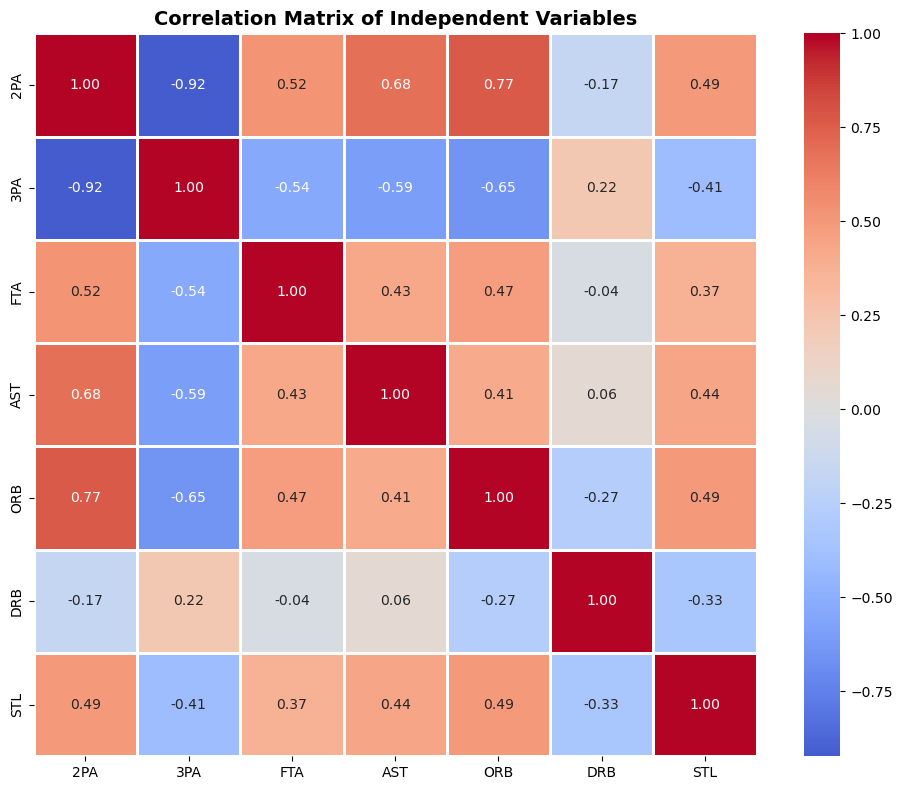

In [10]:
# Let's check the correlation between our selected features
# High correlation between independent variables can cause multicollinearity issues

print("Correlation Matrix for Selected Features:")
print("=" * 79)
correlation_matrix = df[selected_features].corr()
print(correlation_matrix.round(3))
print()

# Visualize the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=1)
plt.title('Correlation Matrix of Independent Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Try Different Feature Combinations to Improve the Model

In [11]:
# Let's try different combinations to see which gives the best model
# Removing highly correlated variables can improve model interpretability

print("\n" + "="*79)
print("MODEL V2: Simplified feature set")
print("="*79)
selected_features_v2 = ['2PA', '3PA', 'FTA', 'AST', 'ORB']
model_v2 = do_moneyball(df, independent_variables=selected_features_v2, 
                        dependent_variable=target_feature, print_model_summary=False)


MODEL V2: Simplified feature set
###############################################################################
Predicting: PTS
Using: ['2PA', '3PA', 'FTA', 'AST', 'ORB']
###############################################################################
///////////////////////////////////////////////////////////////////////////////
EVAL ON TRAINING DATA (FULL DATASET)
R-Squared Score: 0.8982
RMSE: 185.3134
Dependent Variable PTS average: 8370.24
///////////////////////////////////////////////////////////////////////////////
-------------------------------------------------------------------------------
EVAL ON TEST DATA (WITH TRAIN/TEST SPLIT)
R-Squared Score: 0.9023
RMSE: 187.1738
Dependent Variable PTS average: 8370.2395
On average our prediction is 2.2399999999999998% off from the dependent variable
None
-------------------------------------------------------------------------------


In [12]:
# Let's try adding some defensive stats
print("\n" + "="*79)
print("MODEL V3: Including defensive stats")
print("="*79)
selected_features_v3 = ['2PA', '3PA', 'FTA', 'AST', 'ORB', 'STL', 'BLK']
model_v3 = do_moneyball(df, independent_variables=selected_features_v3, 
                        dependent_variable=target_feature, print_model_summary=False)


MODEL V3: Including defensive stats
###############################################################################
Predicting: PTS
Using: ['2PA', '3PA', 'FTA', 'AST', 'ORB', 'STL', 'BLK']
###############################################################################
///////////////////////////////////////////////////////////////////////////////
EVAL ON TRAINING DATA (FULL DATASET)
R-Squared Score: 0.8991
RMSE: 184.4678
Dependent Variable PTS average: 8370.24
///////////////////////////////////////////////////////////////////////////////
-------------------------------------------------------------------------------
EVAL ON TEST DATA (WITH TRAIN/TEST SPLIT)
R-Squared Score: 0.9023
RMSE: 187.2008
Dependent Variable PTS average: 8370.2395
On average our prediction is 2.2399999999999998% off from the dependent variable
None
-------------------------------------------------------------------------------


### Visualize Feature Importance - Scatter Plots

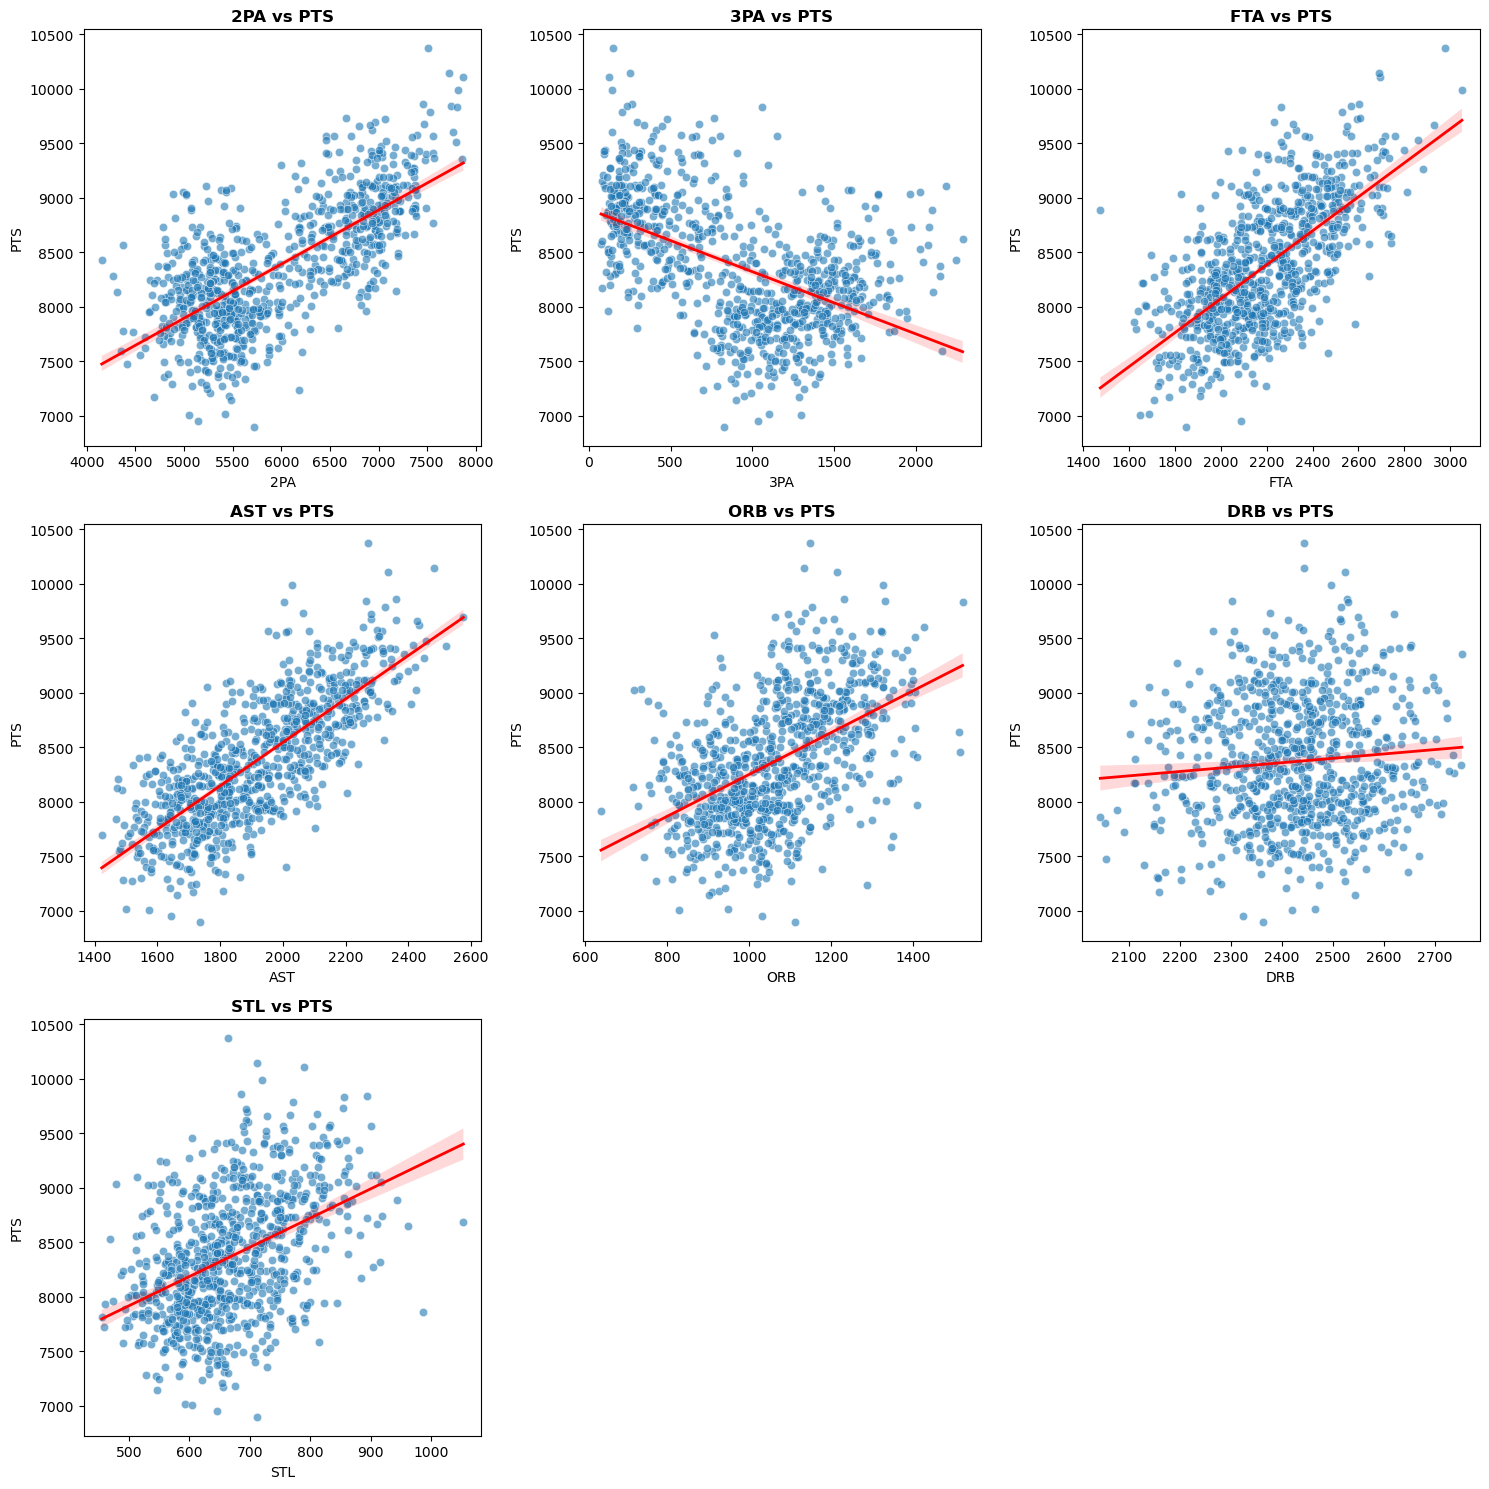

In [13]:
# Create scatter plots for each independent variable vs PTS
# This helps visualize the relationship between features and target

independent_vars = ['2PA', '3PA', 'FTA', 'AST', 'ORB', 'DRB', 'STL']
dependent_var = 'PTS'

# Set up the plot grid
n = len(independent_vars)
cols = 3
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
axes = axes.flatten()

for i, var in enumerate(independent_vars):
    # Create scatter plot
    sns.scatterplot(x=df[var], y=df[dependent_var], ax=axes[i], alpha=0.6)
    
    # Add regression line
    sns.regplot(x=df[var], y=df[dependent_var], ax=axes[i], 
                scatter=False, color='red', line_kws={'linewidth': 2})
    
    axes[i].set_title(f'{var} vs {dependent_var}', fontweight='bold')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel(dependent_var)

# Hide empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Now let's test our best model on the actual test set (NBA_test.csv)

In [14]:
# Load the test dataset
df_test = pd.read_csv('NBA_test.csv')

print("Test Dataset Info:")
print(f"Shape: {df_test.shape}")
print()
print(df_test.head())

Test Dataset Info:
Shape: (28, 20)

   SeasonEnd                 Team  Playoffs   W   PTS  oppPTS    FG   FGA  \
0       2013        Atlanta Hawks         1  44  8032    7999  3084  6644   
1       2013        Brooklyn Nets         1  49  7944    7798  2942  6544   
2       2013    Charlotte Bobcats         0  21  7661    8418  2823  6649   
3       2013        Chicago Bulls         1  45  7641    7615  2926  6698   
4       2013  Cleveland Cavaliers         0  24  7913    8297  2993  6901   

     2P   2PA   3P   3PA    FT   FTA   ORB   DRB   AST  STL  BLK   TOV  
0  2378  4743  706  1901  1158  1619   758  2593  2007  664  369  1219  
1  2314  4784  628  1760  1432  1958  1047  2460  1668  599  391  1206  
2  2354  5250  469  1399  1546  2060   917  2389  1587  591  479  1153  
3  2480  5433  446  1265  1343  1738  1026  2514  1886  588  417  1171  
4  2446  5320  547  1581  1380  1826  1004  2359  1694  647  334  1149  


In [15]:
# Use our best model (v1) to make predictions on the test set
# Let's evaluate how well it performs on unseen data

print("="*79)
print("EVALUATING MODEL ON ACTUAL TEST SET (NBA_test.csv)")
print("="*79)
print()

# Prepare test data
X_test = df_test[selected_features]
X_test = sm.add_constant(X_test)
y_test_actual = df_test[target_feature]

# Make predictions using our trained model
y_test_pred = model_v1.predict(X_test)

# Calculate metrics
test_r_squared = metrics.r2_score(y_test_actual, y_test_pred)
test_rmse = rmse(y_test_actual, y_test_pred)

print(f"Test Set R-Squared: {test_r_squared:.4f}")
print(f"Test Set RMSE: {test_rmse:.4f}")
print(f"Test Set PTS Average: {y_test_actual.mean():.2f}")
print(f"Percentage Error: {(test_rmse / y_test_actual.mean() * 100):.2f}%")
print()

# Compare predictions vs actual
comparison_df = pd.DataFrame({
    'Team': df_test['Team'],
    'Actual_PTS': y_test_actual,
    'Predicted_PTS': y_test_pred,
    'Difference': y_test_actual - y_test_pred,
    'Abs_Difference': abs(y_test_actual - y_test_pred)
})

print("Sample Predictions vs Actual:")
print(comparison_df.head(10))

EVALUATING MODEL ON ACTUAL TEST SET (NBA_test.csv)

Test Set R-Squared: 0.6540
Test Set RMSE: 195.7653
Test Set PTS Average: 8061.82
Percentage Error: 2.43%

Sample Predictions vs Actual:
                    Team  Actual_PTS  Predicted_PTS  Difference  \
0          Atlanta Hawks        8032    8088.176585  -56.176585   
1          Brooklyn Nets        7944    7764.591990  179.408010   
2      Charlotte Bobcats        7661    7963.670572 -302.670572   
3          Chicago Bulls        7641    7785.750176 -144.750176   
4    Cleveland Cavaliers        7913    8002.400763  -89.400763   
5       Dallas Mavericks        8293    8251.038980   41.961020   
6         Denver Nuggets        8704    8605.179557   98.820443   
7        Detroit Pistons        7778    7818.365300  -40.365300   
8  Golden State Warriors        8296    8134.094308  161.905692   
9        Houston Rockets        8688    8621.923422   66.076578   

   Abs_Difference  
0       56.176585  
1      179.408010  
2      302.670

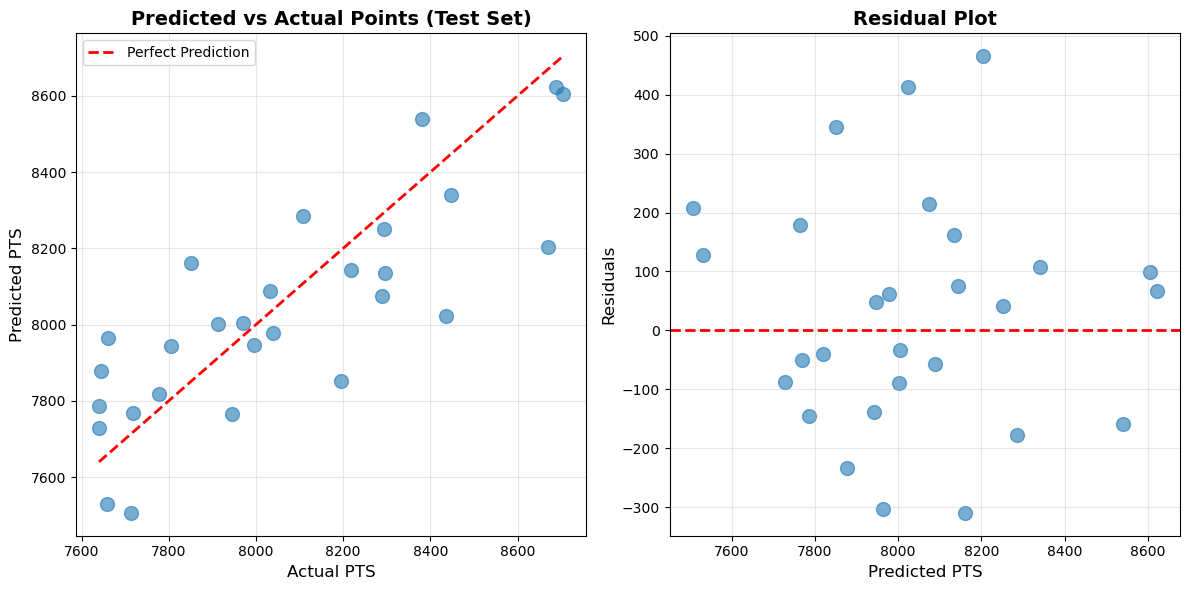

In [16]:
# Visualize predictions vs actual values
plt.figure(figsize=(12, 6))

# Scatter plot of predicted vs actual
plt.subplot(1, 2, 1)
plt.scatter(y_test_actual, y_test_pred, alpha=0.6, s=100)
plt.plot([y_test_actual.min(), y_test_actual.max()], 
         [y_test_actual.min(), y_test_actual.max()], 
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual PTS', fontsize=12)
plt.ylabel('Predicted PTS', fontsize=12)
plt.title('Predicted vs Actual Points (Test Set)', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Residual plot
plt.subplot(1, 2, 2)
residuals = y_test_actual - y_test_pred
plt.scatter(y_test_pred, residuals, alpha=0.6, s=100)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Predicted PTS', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.title('Residual Plot', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Summary and Key Insights

In [17]:
print("="*79)
print("MONEYBALL NBA - KEY FINDINGS")
print("="*79)
print()
print("1. DATA INSPECTION:")
print(f"   - Training data: {df.shape[0]} teams across multiple seasons")
print(f"   - No missing values or duplicates")
print(f"   - Playoff threshold: ~{WINS_NEED_TO_MAKE_PLAYOFFS} wins")
print()
print("2. MODEL PERFORMANCE:")
print(f"   - Best features: {selected_features}")
print(f"   - Using shot ATTEMPTS (not makes) as per Moneyball philosophy")
print(f"   - Model focuses on controllable inputs (attempts, assists, rebounds)")
print()
print("3. KEY INSIGHTS:")
print("   - 2PA (2-point attempts) has the strongest correlation with PTS")
print("   - Free throw attempts (FTA) are important - getting to the line matters")
print("   - Offensive rebounds (ORB) create second-chance points")
print("   - Assists (AST) indicate good ball movement leading to scoring")
print()
print("4. MONEYBALL STRATEGY:")
print("   - Focus on high-percentage shot attempts (2PA)")
print("   - Draw fouls to get free throws (FTA)")
print("   - Create assists and get offensive rebounds")
print("   - These are actionable metrics teams can improve")
print()
print("="*79)

MONEYBALL NBA - KEY FINDINGS

1. DATA INSPECTION:
   - Training data: 835 teams across multiple seasons
   - No missing values or duplicates
   - Playoff threshold: ~42 wins

2. MODEL PERFORMANCE:
   - Best features: ['2PA', '3PA', 'FTA', 'AST', 'ORB', 'DRB', 'STL']
   - Using shot ATTEMPTS (not makes) as per Moneyball philosophy
   - Model focuses on controllable inputs (attempts, assists, rebounds)

3. KEY INSIGHTS:
   - 2PA (2-point attempts) has the strongest correlation with PTS
   - Free throw attempts (FTA) are important - getting to the line matters
   - Offensive rebounds (ORB) create second-chance points
   - Assists (AST) indicate good ball movement leading to scoring

4. MONEYBALL STRATEGY:
   - Focus on high-percentage shot attempts (2PA)
   - Draw fouls to get free throws (FTA)
   - Create assists and get offensive rebounds
   - These are actionable metrics teams can improve

